## **Install MySQL Connector**

In [1]:
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


## **Important Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20, 10

## **Create SQL**

In [3]:
sql= "select * from acc_ord_card_disp_client_dist aocdcd join loan_trans lt on lt.account_id= aocdcd.account_id"

## **Create Connection and Read Data as data Frame**

In [4]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Pajju@02",
    database="capstone_project_prajwal"
)

print("Connected successfully")
conn.close()

Connected successfully


In [6]:
import mysql.connector as connection
try:
    mydb = connection.connect(host="localhost",database = 'capstone_project_prajwal',user="root",passwd="Pajju@02",use_pure=True)
    df = pd.read_sql(sql,mydb)
    mydb.close() # close the connection
except Exception as e:
    mydb.close()
    print(str(e)) 

C:\Users\pmgho\AppData\Local\Temp\ipykernel_6324\1690420554.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql,mydb)


## **Display Data**

In [7]:
display (df)

,card_id,disp_id,type,issued,account_id,disposition_client_id,disposition_type,client_id,birth_number,district_id,...,balance,k_symbol,bank,account,loan_id,loan_date,loan_amount,duration,payments,status
0,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19917,UROK,,,5325,930803,105804,36,2939,A
1,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,26099,,,,5325,930803,105804,36,2939,A
2,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19799,,,,5325,930803,105804,36,2939,A
3,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,24499,SIPO,QR,62958741,5325,930803,105804,36,2939,A
4,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,31493,UVER,QR,70984434,5325,930803,105804,36,2939,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1036,9735,classic,970117 00:00:00,8129,10043,OWNER,10043,651029,45,...,700,,,,6668,940730,74736,36,2076,A
864,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,54840,,GH,84269058,6678,940520,80340,12,6695,A
865,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,14000,,,,6678,940520,80340,12,6695,A
866,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,1100,,,,6678,940520,80340,12,6695,A


## **Display Shape** 

In [8]:
display (df.shape)

(868, 50)

## **Display all columns**

In [9]:
df.columns

Index(['card_id', 'disp_id', 'type', 'issued', 'account_id',
       'disposition_client_id', 'disposition_type', 'client_id',
       'birth_number', 'district_id', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7',
       'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'order_id',
       'bank_to', 'account_to', 'amount', 'k_symbol', 'account_date',
       'account_district_id', 'frequency', 'trans_id', 'account_id', 'date',
       'type', 'operation', 'amount', 'balance', 'k_symbol', 'bank', 'account',
       'loan_id', 'loan_date', 'loan_amount', 'duration', 'payments',
       'status'],
      dtype='object')

## **Display Null values** 

In [10]:
print (df.isnull().sum()) 

card_id                  0
disp_id                  0
type                     0
issued                   0
account_id               0
disposition_client_id    0
disposition_type         0
client_id                0
birth_number             0
district_id              0
A1                       0
A2                       0
A3                       0
A4                       0
A5                       0
A6                       0
A7                       0
A8                       0
A9                       0
A10                      0
A11                      0
A12                      0
A13                      0
A14                      0
A15                      0
A16                      0
order_id                 0
bank_to                  0
account_to               0
amount                   0
k_symbol                 0
account_date             0
account_district_id      0
frequency                0
trans_id                 0
account_id               0
date                     0
t

## **Create x – independent variable**

In [11]:
x=df[['loan_amount','balance']].values
display (x)

array([[105804,  19917],
       [105804,  26099],
       [105804,  19799],
       ...,
       [ 80340,  14000],
       [ 80340,   1100],
       [ 28248,    400]], dtype=int64)

## **Min Max Scaler** 

In [12]:
from sklearn.preprocessing import MinMaxScaler
minmax= MinMaxScaler()
minmax_x = minmax.fit_transform(x)
print (minmax_x)

[[0.28768316 0.13749076]
 [0.28768316 0.18059914]
 [0.28768316 0.13666792]
 ...
 [0.20733785 0.09623028]
 [0.20733785 0.00627589]
 [0.04297452 0.00139464]]


## **Elbow method -WCSS**

In [13]:
wcss = []
for i in range(2,15):
    kmeans = KMeans (n_clusters =  i , init = 'k-means++')
    kmeans.fit(minmax_x)
    wcss.append (kmeans.inertia_)
display (wcss)

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process

[46.114733997710886,
 31.366968669300007,
 24.05153354539627,
 18.924676389579275,
 13.844898167059632,
 11.868937807925677,
 10.444693402200338,
 9.410591490940652,
 7.635128981702238,
 7.6146094020981785,
 5.827237791370739,
 5.7009222057933595,
 5.111169652455892]

## **Plot Graph** 

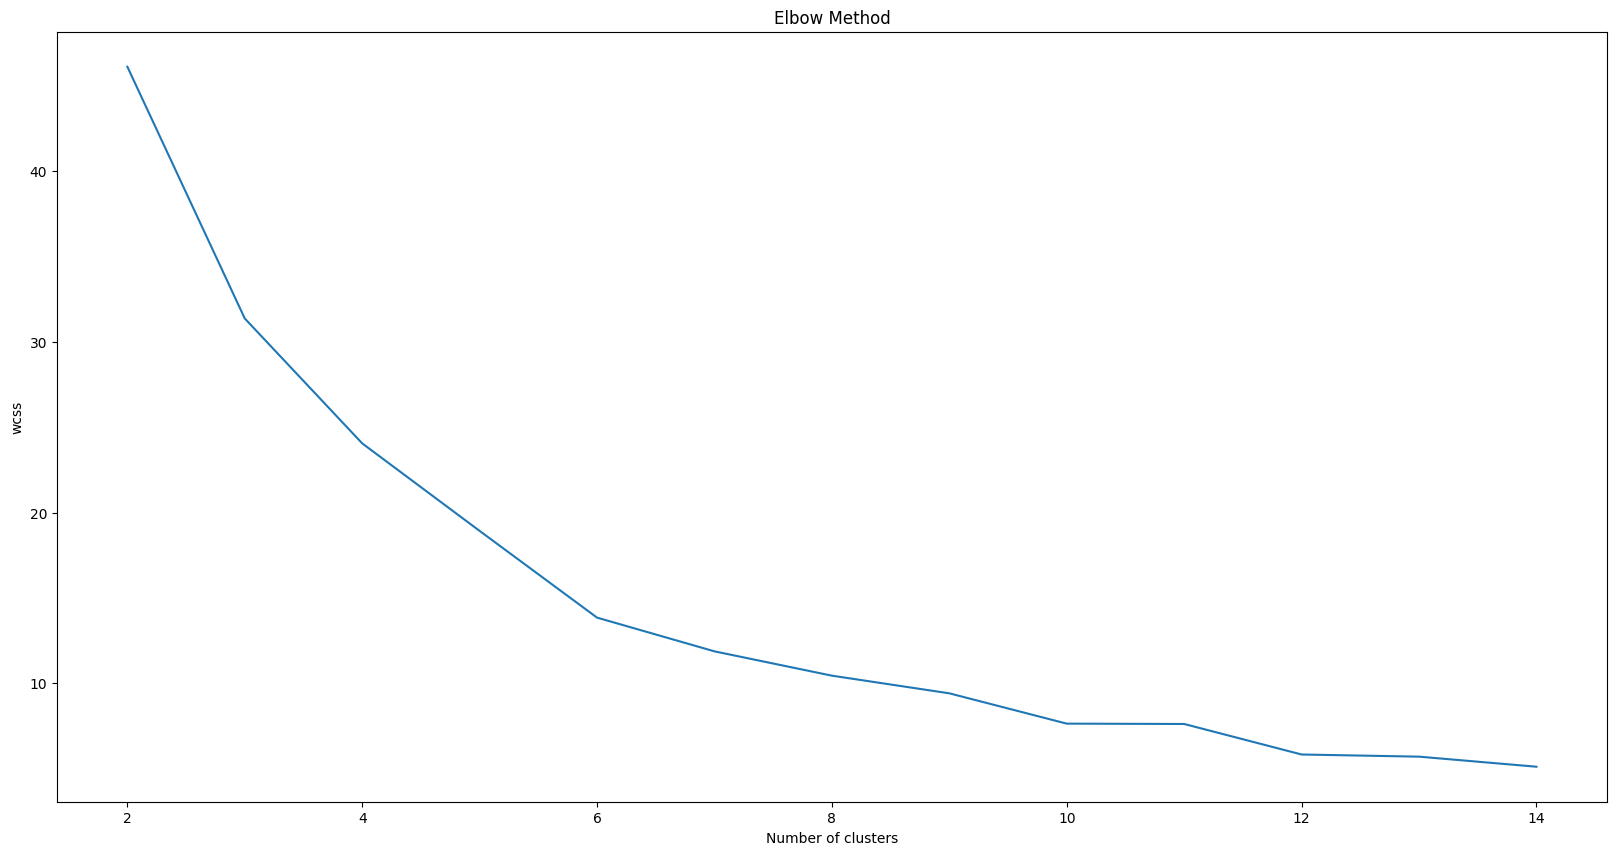

In [14]:
plt.plot (range(2,15),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel ('wcss')
plt.show()

## **Create K Means with 6 Clusters**

In [15]:
kmeans =  KMeans (n_clusters =  6 , init = 'k-means++')
kmeans = kmeans.fit(minmax_x)
y_kmeans =kmeans.labels_
display (y_kmeans)

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


array([5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 5, 0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 5, 5, 5, 3, 0,
       3, 3, 0, 3, 3, 5, 5, 3, 0, 3, 3, 0, 3, 3, 5, 5, 3, 0, 3, 3, 0, 3,
       3, 5, 5, 3, 0, 3, 3, 0, 3, 3, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 5, 5, 5, 0, 0, 3, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 3, 3, 3, 0, 0,
       3, 0, 0, 3, 0, 0, 0, 5, 5, 5, 5, 4, 4, 4, 2, 4, 4, 4, 4, 4, 4, 4,
       2, 4, 4, 2, 2, 4, 4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4, 4, 4,
       4, 4, 4, 4, 2, 4, 4, 2, 2, 4, 4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       2, 4, 4, 4, 4, 4, 4, 4, 2, 4, 4, 2, 2, 4, 4, 2, 4, 4, 4, 4, 4, 4,
       4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       1, 1, 0, 0, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

## **Plot Clusters**  

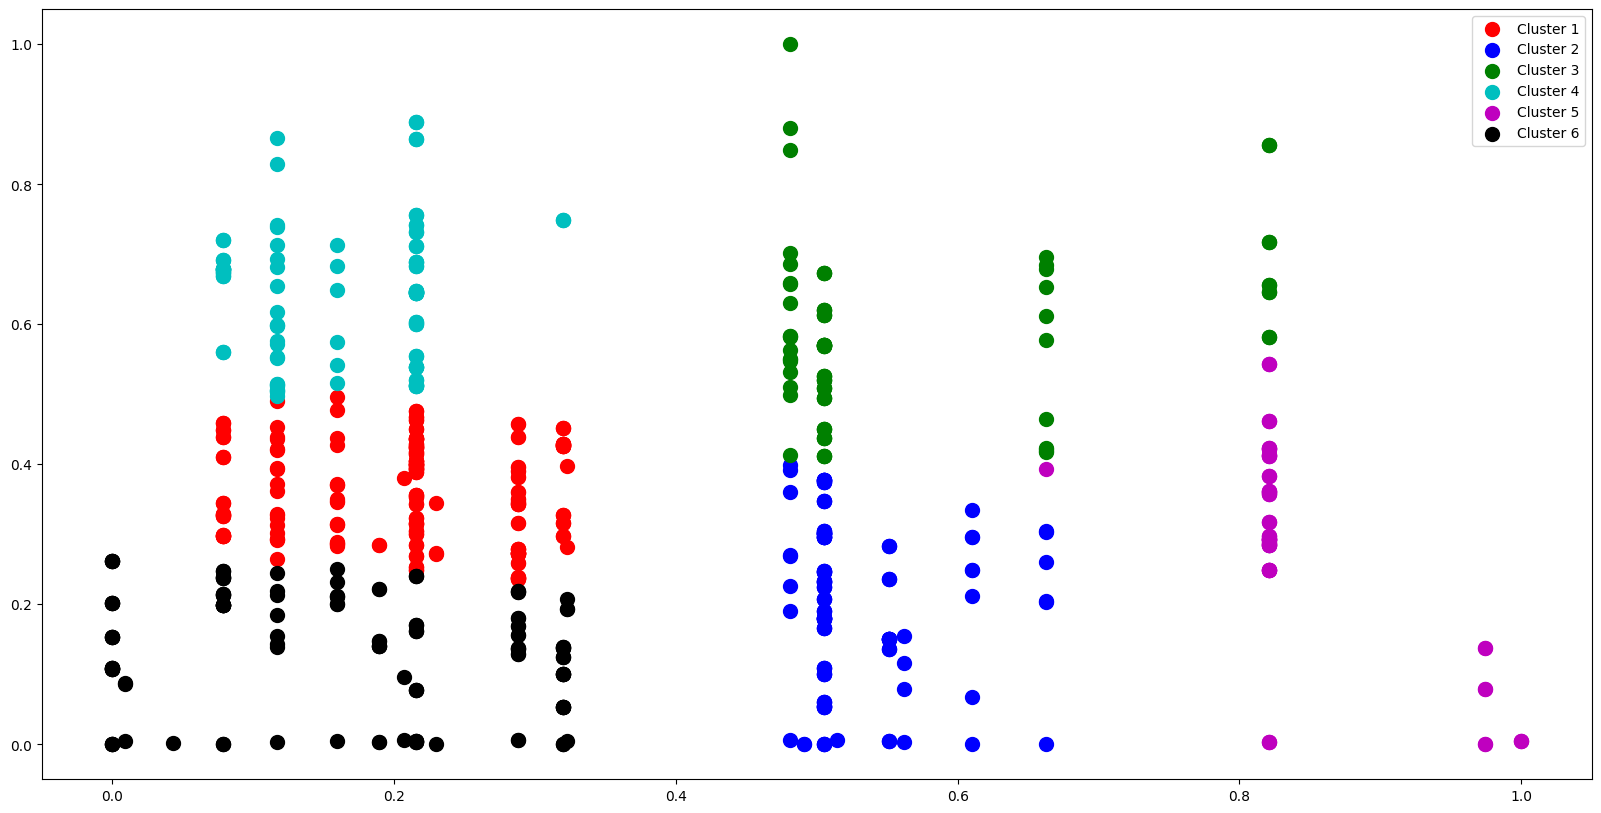

In [16]:
plt.scatter (minmax_x[y_kmeans == 0,0],minmax_x[y_kmeans == 0,1] ,s = 100, c='r', label = 'Cluster 1')
plt.scatter (minmax_x[y_kmeans == 1,0],minmax_x[y_kmeans == 1,1] ,s = 100, c='b', label = 'Cluster 2')
plt.scatter (minmax_x[y_kmeans == 2,0],minmax_x[y_kmeans == 2,1] ,s = 100, c='g', label = 'Cluster 3')
plt.scatter (minmax_x[y_kmeans == 3,0],minmax_x[y_kmeans == 3,1] ,s = 100, c='c', label = 'Cluster 4')
plt.scatter (minmax_x[y_kmeans == 4,0],minmax_x[y_kmeans == 4,1] ,s = 100, c='m', label = 'Cluster 5')
plt.scatter (minmax_x[y_kmeans == 5,0],minmax_x[y_kmeans == 5,1] ,s = 100, c='k', label = 'Cluster 6')
plt.legend()
plt.show()

## **Create Data Frame with Account ID, Loan Amount, Balance and Clusters**

In [18]:
x_final=pd.concat([df.iloc[:,4],pd.DataFrame(x), pd.DataFrame(y_kmeans)], axis =1  )
x_final.columns= ['account_id','loan_amount','balance','cluster']
x_final.to_excel('C:\\Users\\pmgho\\OneDrive\\Desktop\\Prajwal_capstone_sql_project\\K_Means.xlsx',      index =None)
display (x_final)

,account_id,loan_amount,balance,cluster
0,1843,105804,19917,5
1,1843,105804,26099,5
2,1843,105804,19799,5
3,1843,105804,24499,5
4,1843,105804,31493,5
...,...,...,...,...
863,8129,74736,700,5
864,8173,80340,54840,0
865,8173,80340,14000,5
866,8173,80340,1100,5


## **Number of records in cluster**

In [19]:
display (x_final.cluster.value_counts())

cluster
0    255
1    158
5    156
3    129
2     97
4     73
Name: count, dtype: int64

# **Hierarchical Clustering**

## **Create X – Loan Amount and Balance**

In [20]:
x_hc=df[['loan_amount','balance']].values
display (x_hc)

array([[105804,  19917],
       [105804,  26099],
       [105804,  19799],
       ...,
       [ 80340,  14000],
       [ 80340,   1100],
       [ 28248,    400]], dtype=int64)

## **Min Max Scaler** 

In [21]:
from sklearn.preprocessing import MinMaxScaler
minmax= MinMaxScaler()
minmax_x = minmax.fit_transform(x_hc)
print (minmax_x)

[[0.28768316 0.13749076]
 [0.28768316 0.18059914]
 [0.28768316 0.13666792]
 ...
 [0.20733785 0.09623028]
 [0.20733785 0.00627589]
 [0.04297452 0.00139464]]


## **Create Dendrogram with Method – Centroid**

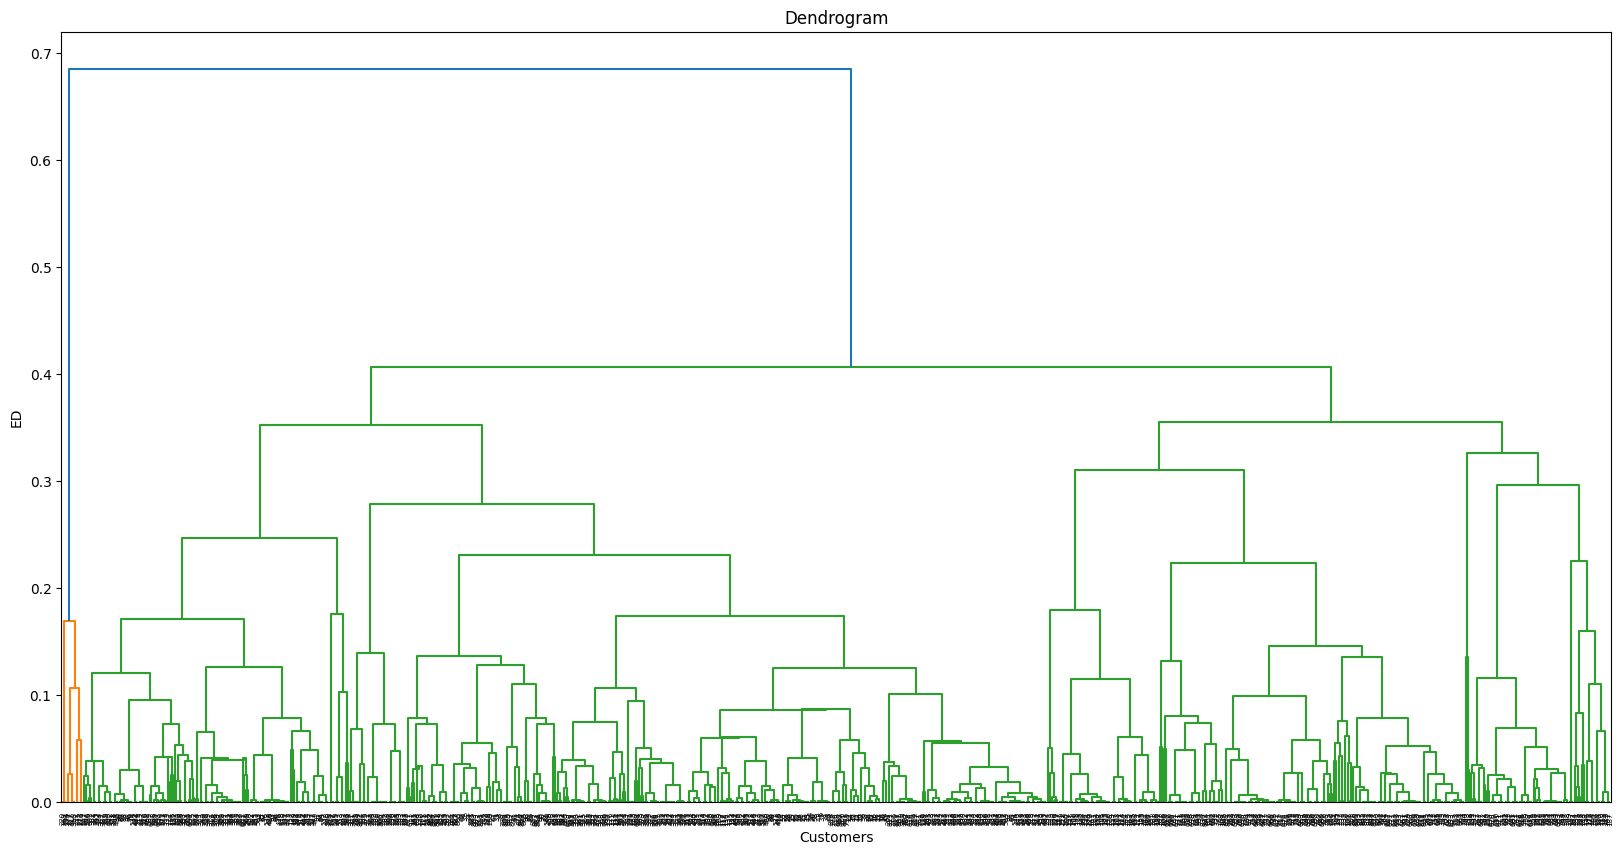

In [22]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(minmax_x, method='centroid'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('ED')
plt.show()

## **Create Dendrogram with Method – Single**

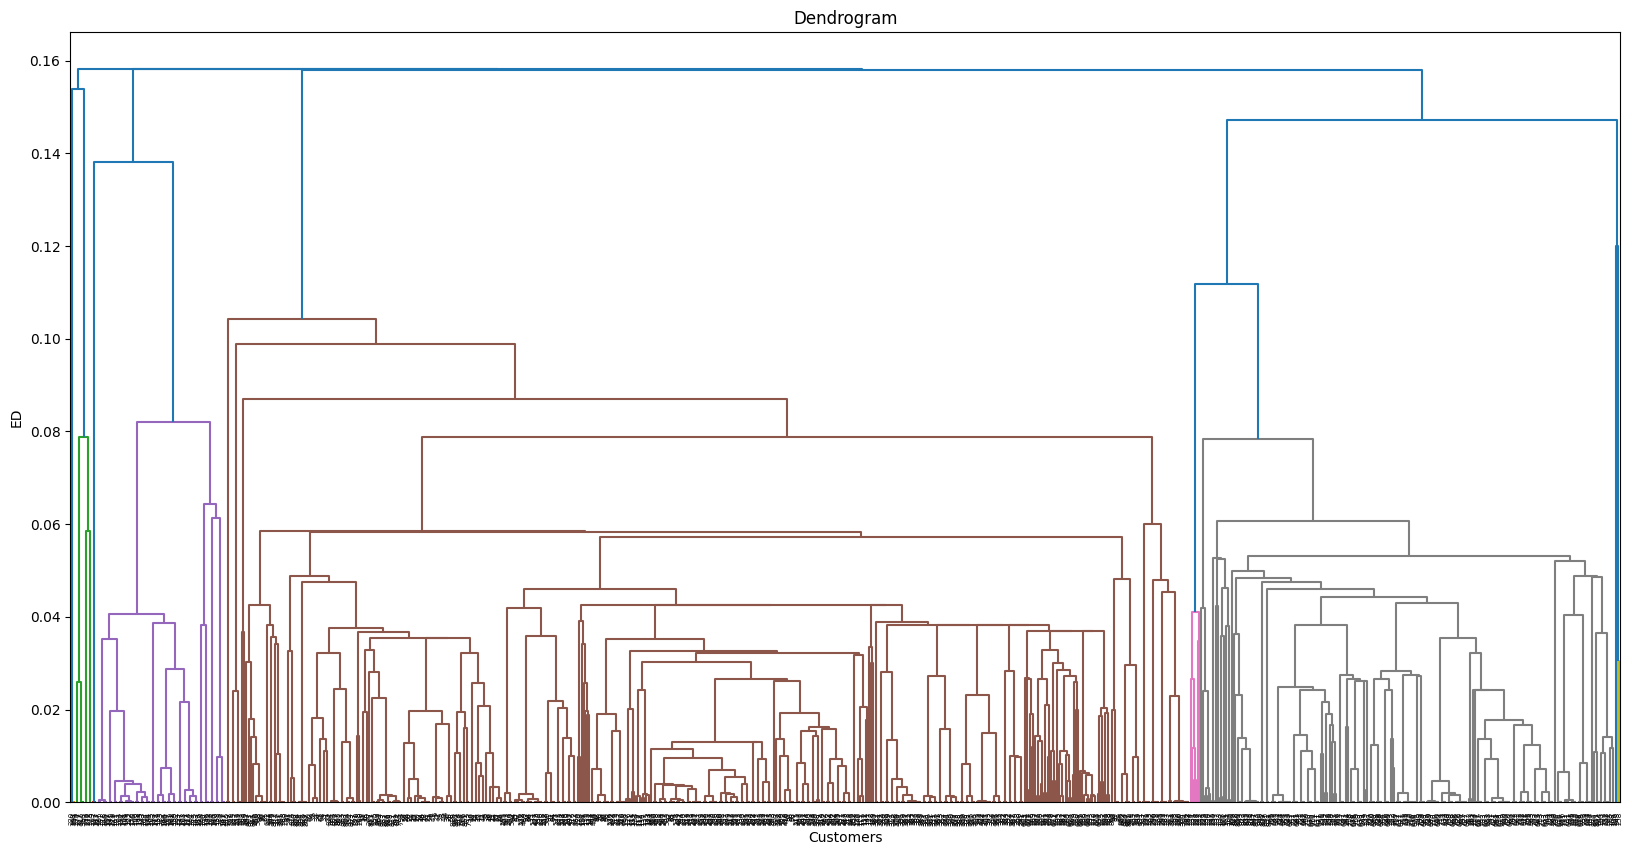

In [26]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(minmax_x, method='single'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('ED')
plt.show()
plt.show()

## **Create Dendrogram with Method – ward**

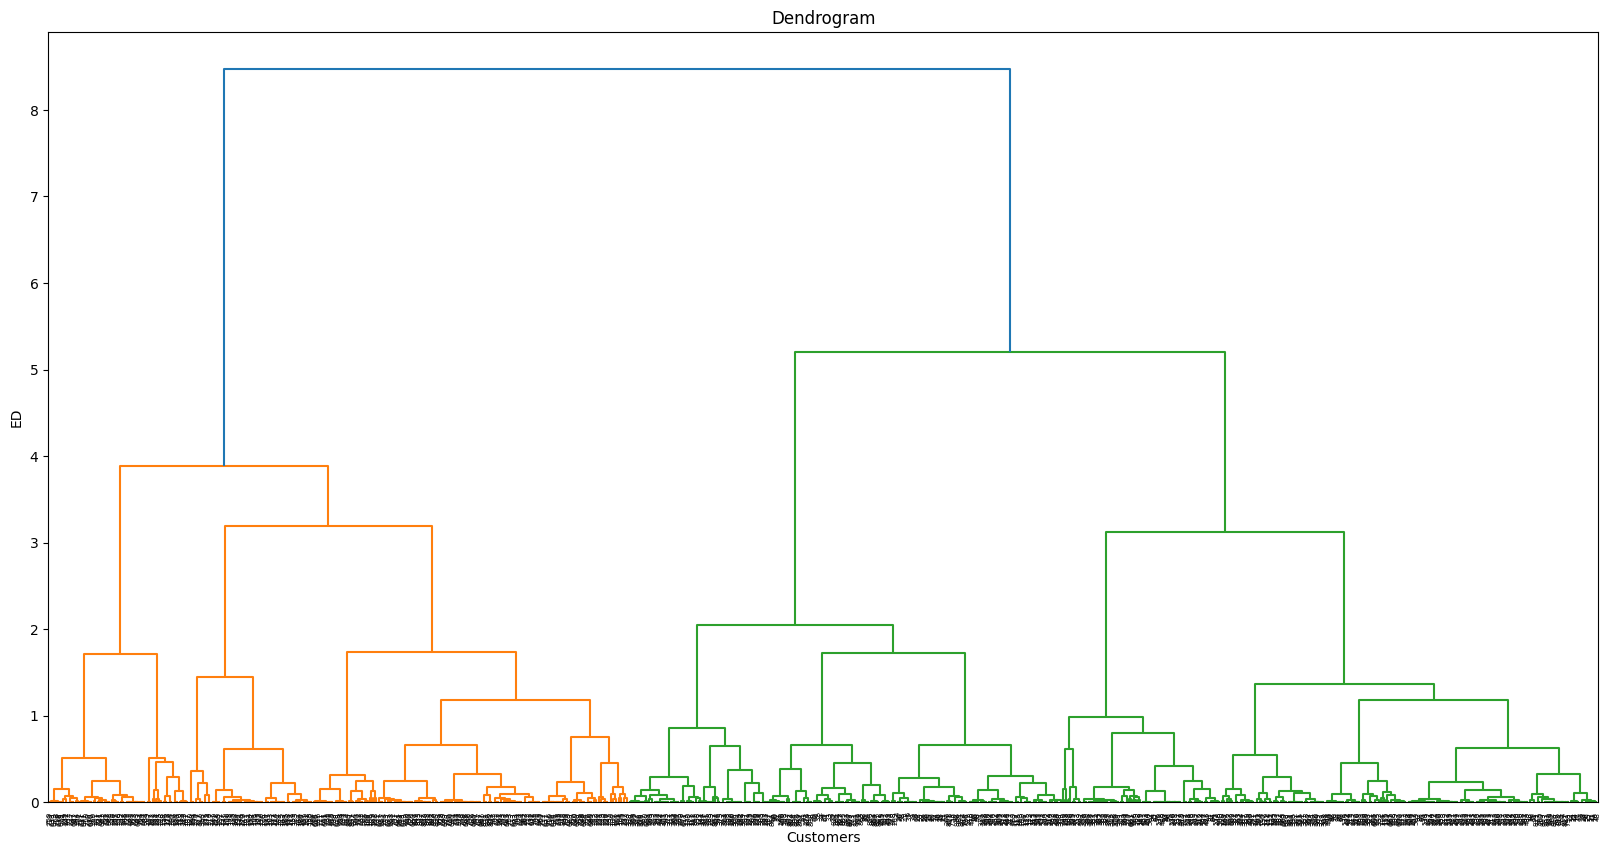

In [27]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(minmax_x, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('ED')
plt.show()

## **Create Dendrogram with Method – Average**

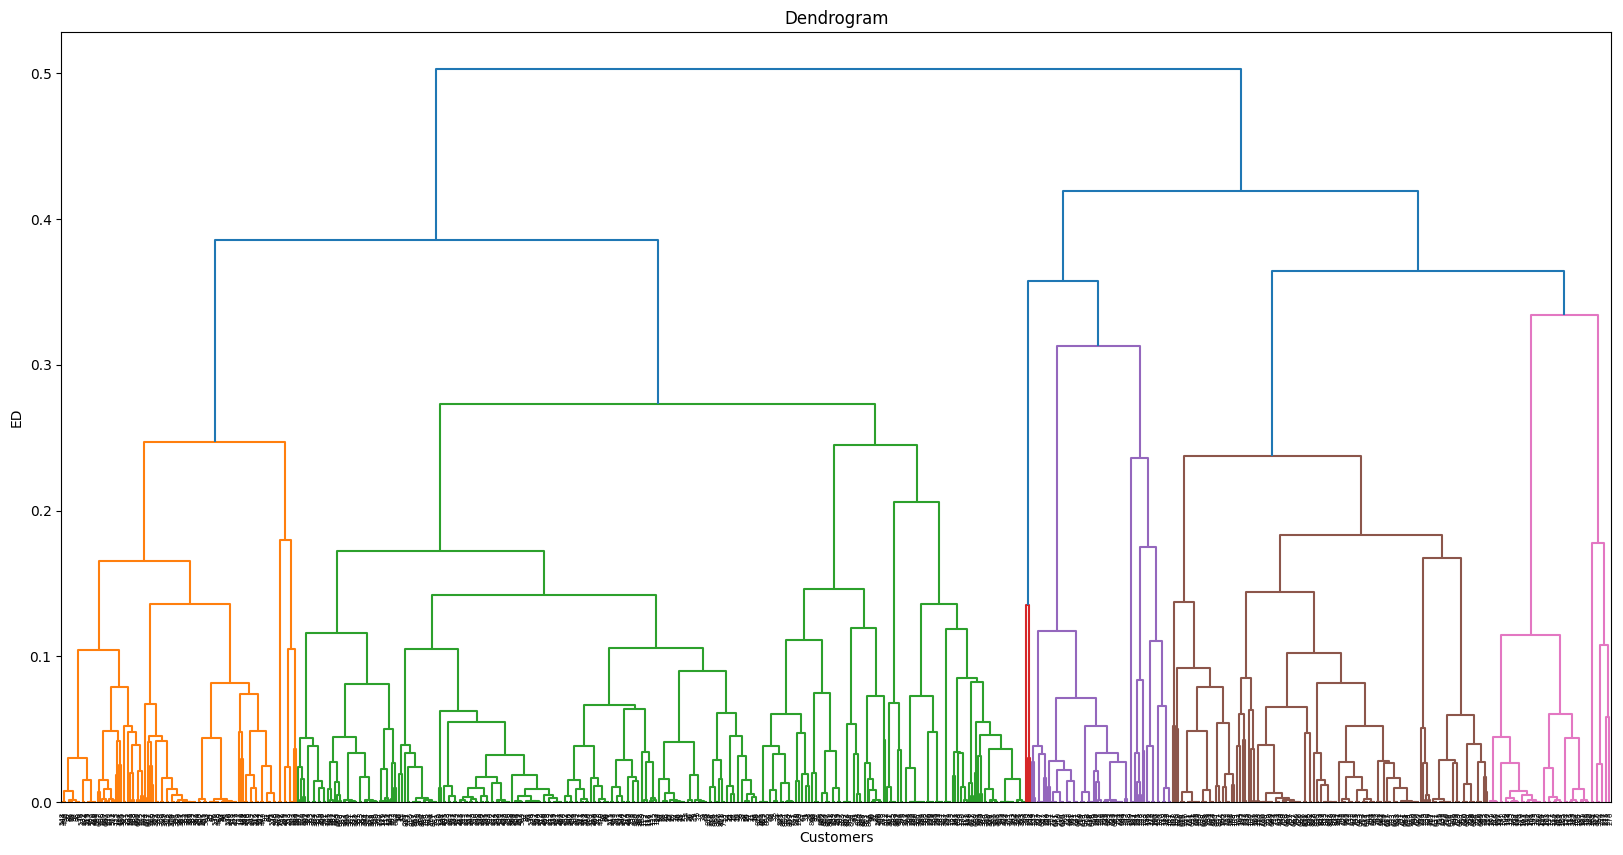

In [28]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(minmax_x, method='average'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('ED')
plt.show()

## **AgglomerativeClustering with Linkage = ward**

In [29]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(minmax_x)
display (y_hc)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## **Value Count -Number of records in Each cluster** 

In [30]:
pd.DataFrame(y_hc).value_counts()

0
0    543
1    325
Name: count, dtype: int64

## **Plot Graph** 

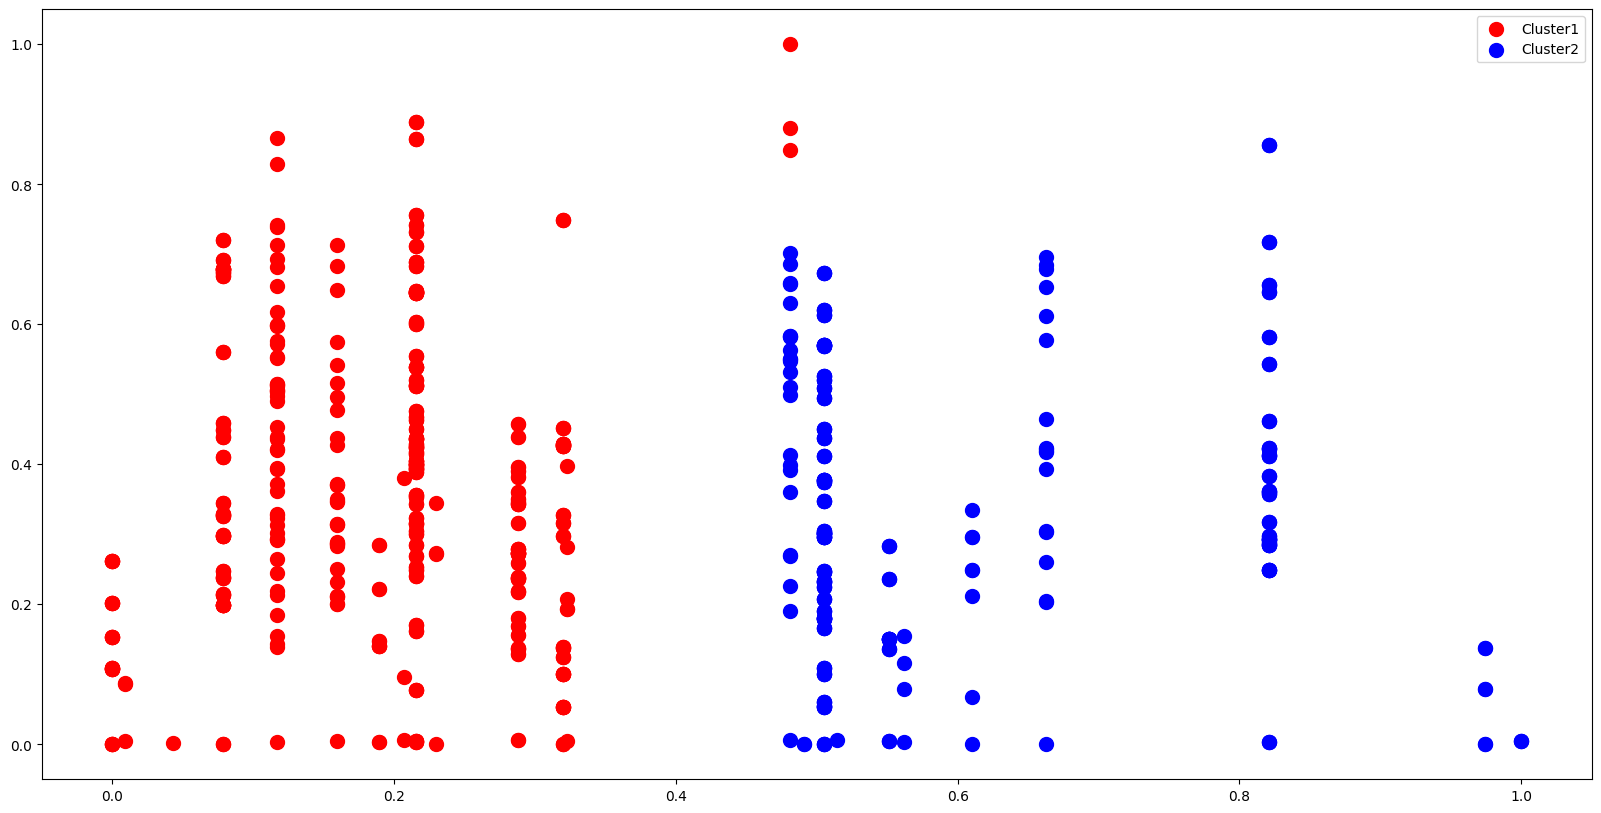

In [31]:
plt.scatter(minmax_x [y_hc==0,0], minmax_x [y_hc==0,1], s=100, c='red', label='Cluster1')
plt.scatter(minmax_x [y_hc==1,0], minmax_x [y_hc==1,1], s=100, c='blue', label='Cluster2')
plt.legend()
plt.show()

## **AgglomerativeClustering with Linkage = Average** 

In [32]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, metric ='euclidean', linkage='average')
y_hc = hc.fit_predict(minmax_x)
display (y_hc)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## **Value Count -Number of records in Each cluster**

In [33]:
pd.DataFrame(y_hc).value_counts()

0
1    540
0    328
Name: count, dtype: int64

## **Plot Graph**

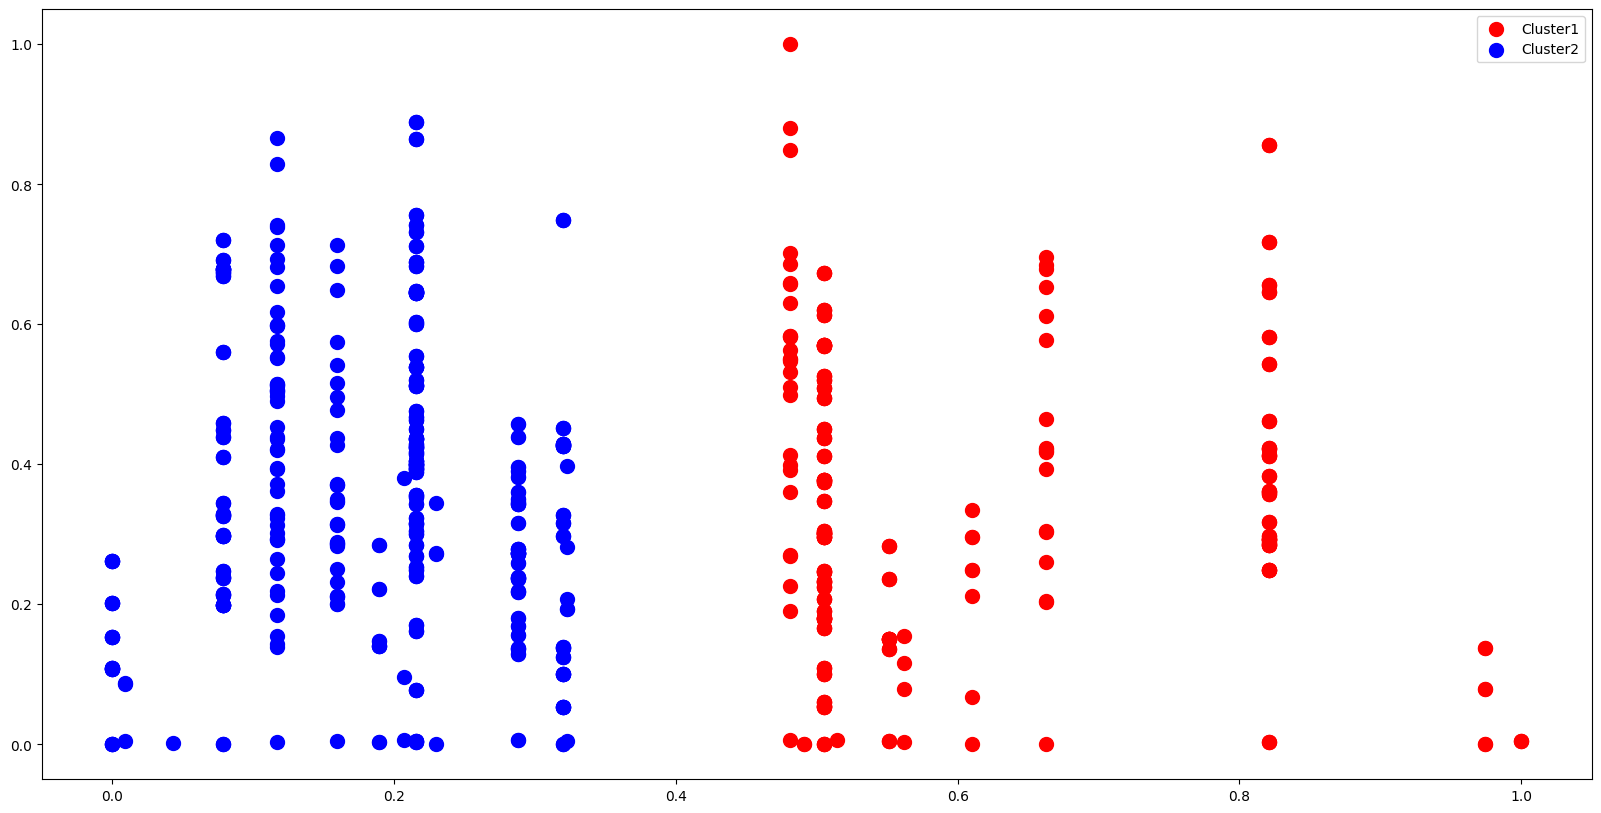

In [34]:
plt.scatter(minmax_x[y_hc==0,0], minmax_x [y_hc==0,1], s=100, c='red', label='Cluster1')
plt.scatter(minmax_x [y_hc==1,0], minmax_x [y_hc==1,1], s=100, c='blue', label='Cluster2')
plt.legend()
plt.show()

## **Display the cluster and export Data to Excel** 

In [35]:
xhc_final=pd.concat([df.iloc[:,4],pd.DataFrame(x_hc), pd.DataFrame(y_hc)], axis =1  )
xhc_final.columns= ['account_id','loan_amount','balance','cluster']
xhc_final.to_excel('C:\\Users\\pmgho\\OneDrive\\Desktop\\Prajwal_capstone_sql_project\\hc.xlsx',index =None)
display (xhc_final)

,account_id,loan_amount,balance,cluster
0,1843,105804,19917,1
1,1843,105804,26099,1
2,1843,105804,19799,1
3,1843,105804,24499,1
4,1843,105804,31493,1
...,...,...,...,...
863,8129,74736,700,1
864,8173,80340,54840,1
865,8173,80340,14000,1
866,8173,80340,1100,1
